## Topic: Real-World Dataset Project (EDA + Data Cleaning)
### Goal of Today

By the end of this session, you will:

- Work with a real dataset
- Perform EDA (Exploratory Data Analysis)
- Clean messy data
- Prepare dataset for ML

### 1. What is EDA (Exploratory Data Analysis)?

👉 EDA = Understanding your data before modeling

#### Why important?
```
Garbage Data → Garbage Model   
Clean Data → Good Model 
```
### 2. Dataset for Today

👉 We will simulate a real-world customer dataset

Features:
- Age
- Salary
- Experience
- Gender
- Purchased

### Tools You Will Use
- Pandas
- Matplotlib

### Step 1: Create Realistic Dataset (with issues)

In [1]:
import pandas as pd

data = {
    "Age": [22, 25, None, 52, 46, 56, 23, None, 40, 60],
    "Salary": [20000, 25000, 70000, None, 65000, 90000, 22000, 40000, None, 95000],
    "Experience": [1, 2, 20, 25, None, 30, 1, 5, 10, None],
    "Gender": ["Male", "Female", "Female", "Male", "Male", None, "Female", "Male", "Female", "Male"],
    "Purchased": [0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)
print(df)

    Age   Salary  Experience  Gender  Purchased
0  22.0  20000.0         1.0    Male          0
1  25.0  25000.0         2.0  Female          0
2   NaN  70000.0        20.0  Female          1
3  52.0      NaN        25.0    Male          1
4  46.0  65000.0         NaN    Male          1
5  56.0  90000.0        30.0    None          1
6  23.0  22000.0         1.0  Female          0
7   NaN  40000.0         5.0    Male          0
8  40.0      NaN        10.0  Female          1
9  60.0  95000.0         NaN    Male          1


### Step 2: Explore Data (EDA)

In [2]:
# Basic info
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         8 non-null      float64
 1   Salary      8 non-null      float64
 2   Experience  8 non-null      float64
 3   Gender      9 non-null      object 
 4   Purchased   10 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 532.0+ bytes
None
             Age        Salary  Experience  Purchased
count   8.000000      8.000000    8.000000  10.000000
mean   40.500000  53375.000000   11.750000   0.600000
std    15.455004  30631.158273   11.658841   0.516398
min    22.000000  20000.000000    1.000000   0.000000
25%    24.500000  24250.000000    1.750000   0.000000
50%    43.000000  52500.000000    7.500000   1.000000
75%    53.000000  75000.000000   21.250000   1.000000
max    60.000000  95000.000000   30.000000   1.000000
Age           2
Salary        2
Experience    2
Gender

What you learn here:

👉 Which columns have missing values

👉 Data types (numeric / categorical)

👉 Data distribution

### Step 3: Handle Missing Values

In [3]:
# Fill numerical missing values with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)
df['Experience'].fillna(df['Experience'].mean(), inplace=True)

# Fill categorical missing values with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

print(df.isnull().sum())

Age           0
Salary        0
Experience    0
Gender        0
Purchased     0
dtype: int64


C:\Users\DELL XPS\AppData\Local\Temp\ipykernel_11164\2009814146.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\DELL XPS\AppData\Local\Temp\ipykernel_11164\2009814146.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

### Explanation:
- Mean → for numbers
- Mode → for categories

### Step 4: Encode Categorical Data

In [4]:
# Convert Gender to numbers
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

print(df.head())

    Age   Salary  Experience  Gender  Purchased
0  22.0  20000.0        1.00       0          0
1  25.0  25000.0        2.00       1          0
2  40.5  70000.0       20.00       1          1
3  52.0  53375.0       25.00       0          1
4  46.0  65000.0       11.75       0          1


### Step 5: Data Visualization

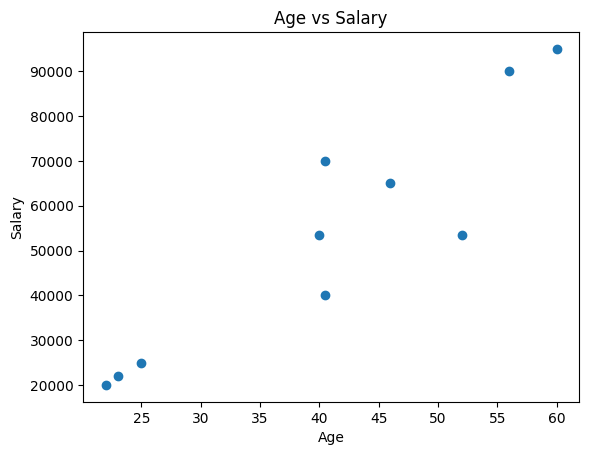

In [5]:
import matplotlib.pyplot as plt

# Simple visualization
plt.scatter(df['Age'], df['Salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

What you see:

👉 Relationship between features

👉 Patterns in data

### Step 7: Train Model

In [7]:
import pandas as pd
import joblib

# Load model and scaler
model = joblib.load("final_model.pkl")
scaler = joblib.load("final_scaler.pkl")

# New user data with correct feature names
new_data = pd.DataFrame([[35, 60000, 10]], 
                        columns=["Age", "Salary", "Experience"])  # match training names

# Apply scaling
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)
print("Final Prediction:", prediction)

Final Prediction: [1]


### What You Learned Today
-  Real dataset is messy
-  Missing values must be handled
-  Categorical data must be encoded
-  Visualization helps understanding

### Real-World Insight

Companies spend:

👉 70% time on data cleaning

👉 30% time on modeling